In [14]:
import sys
sys.path.append("PATH TO src folder")
sys.path.append("PATH TO DIRECTORY CONTAINING THIS NOTEBOOK")


In [15]:
%load_ext autoreload
%autoreload 2

#Setting Up and Importing the Necessary Packages/Libraries
##Package for reading in Bruker OPUS type files
from brukeropusreader import read_file
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline
import pathlib

#Local Functions
from prospecpy.cut_range import cut_range_subtract_prospecpy_objects
from prospecpy.second_deriv import  second_deriv_prospecpy_objects
from prospecpy.baseline import baseline_correction_prospecpy_objects
from prospecpy.peak_fit import gaussian_fit_prospecpy_objects, lorentzian_fit_prospecpy_objects
from prospecpy.io import import_run_data
from prospecpy.interact import interact


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Importing spectra data and water vapor data

# Creating Folders for Data and Plots

Within the data folder, create three more folders, water_vapor, output_plots, and one with a name describing this run or experiment.


In [16]:
# Paths to local data
path_to_water_vapor_data = pathlib.Path("../data/opus_files/water_vapor")
path_to_output_plots = pathlib.Path("../data/output_plots")
path_to_FILL_IN_data = pathlib.Path("../data/opus_files/pD6")

path_to_output_plots.mkdir(parents=True, exist_ok=True)

### Workflow Overview
The function called below `import_run_data`, creates a dict full of ProSpecPy objects, with empty attributes to be completed in the each of the following steps. For each of these steps, the function will write a corresponding plot labeled with the name of the sample to a folder describing the sample and step, within the `output_plots` directory specified above.


In [17]:
FILL_IN_raw_data = import_run_data(
    path_to_FILL_IN_data,
    input_type="raw spectra",
    output_folder="../data/output_plots/"
)

wv_data = import_run_data(path_to_water_vapor_data)

In [18]:
# Exclude problematic sample 011j for demo exploration
demo_raw_data = [
    obj for i, obj in enumerate(FILL_IN_raw_data)
    if i != 9
]

print("Demo data length:", len(demo_raw_data))
for i, obj in enumerate(demo_raw_data):
    print(i, obj.sample_name)

Demo data length: 19
0 011a as iso Hyd2 dark titration 0 mV.0022
1 011b as iso Hyd2 dark titration -50 mV.0004
2 011c as iso Hyd2 dark titration -100 mV.0003
3 011d as iso Hyd2 dark titration -1050mV.0007
4 011e as iso Hyd2 dark titration -200mV.0011
5 011f as iso Hyd2 dark titration -250mV.0008
6 011g as iso Hyd2 dark titration -275mV.0007
7 011h as iso Hyd2 dark titration -300mV.0006
8 011i as iso Hyd2 dark titration -325mV.0008
9 011k as iso Hyd2 dark titration -375mV.0016
10 011l as iso Hyd2 dark titration -400mV.0016
11 011m as iso Hyd2 dark titration -425mV.0018
12 011n as iso Hyd2 dark titration -450mV.0014
13 011o as iso Hyd2 dark titration -475mV.0007
14 011p as iso Hyd2 dark titration -500mV.0007
15 011q as iso Hyd2 dark titration -550mV.0012
16 011r as iso Hyd2 dark titration -600mV.0009
17 011s as iso Hyd2 dark titration -700mV.0009
18 011t as iso Hyd2 dark titration -800mV.0004


In [19]:
print("Raw data type:", type(FILL_IN_raw_data))
print("Raw data length:", len(FILL_IN_raw_data))

print("Water vapour type:", type(wv_data))
print("Water vapour length:", len(wv_data))

for i, obj in enumerate(FILL_IN_raw_data[:3]):
    print(i, type(obj))
    print("has output_folder:", hasattr(obj, "output_folder"))

Raw data type: <class 'list'>
Raw data length: 20
Water vapour type: <class 'dict'>
Water vapour length: 1
0 <class 'prospecpy.prospecpy.ProSpecPy'>
has output_folder: True
1 <class 'prospecpy.prospecpy.ProSpecPy'>
has output_folder: True
2 <class 'prospecpy.prospecpy.ProSpecPy'>
has output_folder: True


# Subtracting water vapor from raw spectra

Make sure to define the desired wave numbers for `range_start` and `range_end` which best fit your sample run.

In [20]:
from prospecpy.cut_range import cut_range_subtract_prospecpy_objects

for i, obj in enumerate(FILL_IN_raw_data):
    print("Testing sample", i, getattr(obj, "sample_name", "NO_SAMPLE_NAME"))
    try:
        cut_range_subtract_prospecpy_objects(
            [obj],
            wv_data,
            range_start=2150,
            range_end=1850,
            showplots=False,
            verbose=True
        )
        print("SUCCESS:", i)
    except Exception as e:
        print("FAILED:", i, getattr(obj, "sample_name", "NO_SAMPLE_NAME"))
        print(type(e).__name__, e)
        break

Testing sample 0 011a as iso Hyd2 dark titration 0 mV.0022
Plot saved to ../data/output_plots//pD6/011a as iso Hyd2 dark titration 0 mV.0022/cut_range_subtracted_spectra
Atmospheric fit parameters saved to ../data/output_plots//pD6/011a as iso Hyd2 dark titration 0 mV.0022/cut_atmfitparameters.csv
Cut subtracted data saved to ../data/output_plots//pD6/011a as iso Hyd2 dark titration 0 mV.0022/cut_subtracted_data.csv
SUCCESS: 0
Testing sample 1 011b as iso Hyd2 dark titration -50 mV.0004
FAILED: 1 011b as iso Hyd2 dark titration -50 mV.0004
IndexError index 0 is out of bounds for axis 0 with size 0


In [21]:
for i in [0, 1]:
    obj = FILL_IN_raw_data[i]
    print("Sample", i, obj.sample_name)
    print("Object type:", type(obj))
    print("Attributes:", [a for a in dir(obj) if "raw" in a.lower() or "data" in a.lower()])
    print()

Sample 0 011a as iso Hyd2 dark titration 0 mV.0022
Object type: <class 'prospecpy.prospecpy.ProSpecPy'>
Attributes: ['cut_subtracted_data', 'get_raw_data', 'raw_data', 'set_raw_data']

Sample 1 011b as iso Hyd2 dark titration -50 mV.0004
Object type: <class 'prospecpy.prospecpy.ProSpecPy'>
Attributes: ['cut_subtracted_data', 'get_raw_data', 'raw_data', 'set_raw_data']



In [22]:
for i in [0, 1]:
    obj = FILL_IN_raw_data[i]
    print("\nSample", i, obj.sample_name)
    print("raw_data type:", type(obj.raw_data))

    if hasattr(obj.raw_data, "keys"):
        print("raw_data keys:", obj.raw_data.keys())

    print("raw_data:", obj.raw_data)


Sample 0 011a as iso Hyd2 dark titration 0 mV.0022
raw_data type: <class 'brukeropusreader.opus_data.OpusData'>
raw_data keys: dict_keys(['Text Information', 'Optik', 'Fourier Transformation', 'Acquisition', 'Sample', 'IgSm', 'IgSm Data Parameter', 'PhSm', 'ScSm', 'AB', 'Instrument (Rf)', 'Optik (Rf)', 'Acquisition (Rf)', 'Fourier Transformation (Rf)', 'IgRf', 'IgRf Data Parameter', 'ScRf Data Parameter', 'ScRf', 'AB Data Parameter', 'ScSm Data Parameter', 'PhSm Data Parameter', 'Instrument', 'History'])
raw_data: {'Text Information': '4\x00\x00x\x00\x00\x00\x18\x00\x00\x00`\x00\x00\x00:\x00\x00\x00ø\x01\x00\x00@\x00\x00\x00\x1e\x00\x00\x00à\x02\x00\x000\x00\x00\x002\x00\x00\x00X\x03\x00\x00\xa0\x00\x00\x00B\x00\x00\x00 \x04\x00\x00\x07\x08\x00\x00\x88;\x00\x00(\x05\x00\x00\x17\x08\x00\x002\x00\x00\x00Hó\x00\x00\x07\x0c\x00\x00\x00\x04\x00\x00\x10ô\x00\x00\x07\x04\x00\x00\x18\x07\x00\x00\x80\x04\x01\x00\x0f\x10\x00\x00\x18\x07\x00\x00P!\x01\x00(\x00\x00\x00\x98\x00\x00\x00 >\x01\x00h\

In [23]:
ranges_to_test = [
    (2150, 1850),
    (2150, 1800),
    (2200, 1800),
    (2100, 1850),
    (2100, 1800),
    (2050, 1800),
]


for range_start, range_end in ranges_to_test:
    print("\nTesting range:", range_start, range_end)
    success = 0
    failed = []

    for i, obj in enumerate(FILL_IN_raw_data):
        try:
            cut_range_subtract_prospecpy_objects(
                [obj],
                wv_data,
                range_start=range_start,
                range_end=range_end,
                showplots=False,
                save=False,
                verbose=False
            )
            success += 1
        except Exception as e:
            failed.append((i, obj.sample_name, type(e).__name__, str(e)))

    print("Success:", success)
    print("Failed:", len(failed))
    for item in failed:
        print(item)


Testing range: 2150 1850
Success: 3
Failed: 17
(1, '011b as iso Hyd2 dark titration -50 mV.0004', 'IndexError', 'index 0 is out of bounds for axis 0 with size 0')
(4, '011e as iso Hyd2 dark titration -200mV.0011', 'IndexError', 'index 0 is out of bounds for axis 0 with size 0')
(5, '011f as iso Hyd2 dark titration -250mV.0008', 'IndexError', 'index 0 is out of bounds for axis 0 with size 0')
(6, '011g as iso Hyd2 dark titration -275mV.0007', 'IndexError', 'index 0 is out of bounds for axis 0 with size 0')
(7, '011h as iso Hyd2 dark titration -300mV.0006', 'IndexError', 'index 0 is out of bounds for axis 0 with size 0')
(8, '011i as iso Hyd2 dark titration -325mV.0008', 'IndexError', 'index 0 is out of bounds for axis 0 with size 0')
(9, '011j as iso Hyd2 dark titration -350mV.0011', 'ValueError', "If mode is 'interp', window_length must be less than or equal to the size of x.")
(10, '011k as iso Hyd2 dark titration -375mV.0016', 'IndexError', 'index 0 is out of bounds for axis 0 with 

In [24]:
obj = FILL_IN_raw_data[9]

print(obj.sample_name)
print(type(obj.raw_data))
print(obj.raw_data["AB Data Parameter"])
print("AB length:", len(obj.raw_data["AB"]))
print("AB first values:", obj.raw_data["AB"][:10])
print("AB last values:", obj.raw_data["AB"][-10:])

011j as iso Hyd2 dark titration -350mV.0011
<class 'brukeropusreader.opus_data.OpusData'>
{'DPF': 1, 'NPT': 183, 'FXV': 1799.280097603798, 'LXV': 2150.265068411827, 'CSF': 1.0, 'MXY': 0.5072941780090332, 'MNY': 0.17504465579986572, 'DAT': '02/08/2018', 'TIM': '04:24:28.799 (GMT+1)', 'DXU': 'WN'}
AB length: 694
AB first values: [1.68155816e-44 2.80259693e-42 1.40129846e-45 6.27109369e-39
 1.83670992e-40 1.17607042e-38 7.37636505e-39 1.83670992e-40
 1.40129846e-45 8.29149843e-39]
AB last values: [3.03524967e+32 1.59748025e-43 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 1.08420217e-19]


In [25]:
# Exclude sample index 9, which is 011j and consistently fails
demo_raw_data = [
    obj for i, obj in enumerate(FILL_IN_raw_data)
    if i != 9
]

print("Demo data length:", len(demo_raw_data))
for i, obj in enumerate(demo_raw_data):
    print(i, obj.sample_name)

Demo data length: 19
0 011a as iso Hyd2 dark titration 0 mV.0022
1 011b as iso Hyd2 dark titration -50 mV.0004
2 011c as iso Hyd2 dark titration -100 mV.0003
3 011d as iso Hyd2 dark titration -1050mV.0007
4 011e as iso Hyd2 dark titration -200mV.0011
5 011f as iso Hyd2 dark titration -250mV.0008
6 011g as iso Hyd2 dark titration -275mV.0007
7 011h as iso Hyd2 dark titration -300mV.0006
8 011i as iso Hyd2 dark titration -325mV.0008
9 011k as iso Hyd2 dark titration -375mV.0016
10 011l as iso Hyd2 dark titration -400mV.0016
11 011m as iso Hyd2 dark titration -425mV.0018
12 011n as iso Hyd2 dark titration -450mV.0014
13 011o as iso Hyd2 dark titration -475mV.0007
14 011p as iso Hyd2 dark titration -500mV.0007
15 011q as iso Hyd2 dark titration -550mV.0012
16 011r as iso Hyd2 dark titration -600mV.0009
17 011s as iso Hyd2 dark titration -700mV.0009
18 011t as iso Hyd2 dark titration -800mV.0004


In [26]:
for i, obj in enumerate(demo_raw_data):
    print("Testing demo sample", i, obj.sample_name)
    try:
        cut_range_subtract_prospecpy_objects(
            [obj],
            wv_data,
            range_start=2150,
            range_end=1800,
            showplots=False,
            save=False,
            verbose=False
        )
        print("SUCCESS:", i)
    except Exception as e:
        print("FAILED:", i, obj.sample_name)
        print(type(e).__name__, e)
        break

Testing demo sample 0 011a as iso Hyd2 dark titration 0 mV.0022
SUCCESS: 0
Testing demo sample 1 011b as iso Hyd2 dark titration -50 mV.0004
SUCCESS: 1
Testing demo sample 2 011c as iso Hyd2 dark titration -100 mV.0003
SUCCESS: 2
Testing demo sample 3 011d as iso Hyd2 dark titration -1050mV.0007
SUCCESS: 3
Testing demo sample 4 011e as iso Hyd2 dark titration -200mV.0011
SUCCESS: 4
Testing demo sample 5 011f as iso Hyd2 dark titration -250mV.0008
SUCCESS: 5
Testing demo sample 6 011g as iso Hyd2 dark titration -275mV.0007
SUCCESS: 6
Testing demo sample 7 011h as iso Hyd2 dark titration -300mV.0006
SUCCESS: 7
Testing demo sample 8 011i as iso Hyd2 dark titration -325mV.0008
SUCCESS: 8
Testing demo sample 9 011k as iso Hyd2 dark titration -375mV.0016
SUCCESS: 9
Testing demo sample 10 011l as iso Hyd2 dark titration -400mV.0016
SUCCESS: 10
Testing demo sample 11 011m as iso Hyd2 dark titration -425mV.0018
SUCCESS: 11
Testing demo sample 12 011n as iso Hyd2 dark titration -450mV.0014
SUCCE

In [27]:
cut_range_subtract_prospecpy_objects(
    demo_raw_data,
    wv_data,
    range_start=2150,
    range_end=1800,
    showplots=False,
    save=False,
    verbose=True
)

## Get the second derivatives

In [28]:
second_deriv_prospecpy_objects(demo_raw_data, show_plots=False, verbose = True)

Plot saved to ../data/output_plots//pD6/011a as iso Hyd2 dark titration 0 mV.0022/subtracted_spectra
Plot saved to ../data/output_plots//pD6/011a as iso Hyd2 dark titration 0 mV.0022/second_derivative_fig
Second derivative csv data saved to ../data/output_plots//pD6/011a as iso Hyd2 dark titration 0 mV.0022/second_derivative_data.csv
Plot saved to ../data/output_plots//pD6/011b as iso Hyd2 dark titration -50 mV.0004/subtracted_spectra
Plot saved to ../data/output_plots//pD6/011b as iso Hyd2 dark titration -50 mV.0004/second_derivative_fig
Second derivative csv data saved to ../data/output_plots//pD6/011b as iso Hyd2 dark titration -50 mV.0004/second_derivative_data.csv
Plot saved to ../data/output_plots//pD6/011c as iso Hyd2 dark titration -100 mV.0003/subtracted_spectra
Plot saved to ../data/output_plots//pD6/011c as iso Hyd2 dark titration -100 mV.0003/second_derivative_fig
Second derivative csv data saved to ../data/output_plots//pD6/011c as iso Hyd2 dark titration -100 mV.0003/seco

## Using a user interface please select the appropriate number of peaks using the threshold variable and number of anchor points using adjustment factor variable

Be sure to do this for each sample in the run, otherwise the notebook will give you some warnings.

ToggleButtons(description='Step 1. File selection:', options=('011a as iso Hyd2 dark titration 0 mV.0022', '01…

Output()

BoundedFloatText(value=0.4, description='Threshold for peak selection(0.01 to 1 in 0.01 steps):', layout=Layou…

BoundedFloatText(value=1.8, description='adj for anchor point selection(0.01 to 5 in 0.01 steps):', layout=Lay…

Button(description='Save', style=ButtonStyle())

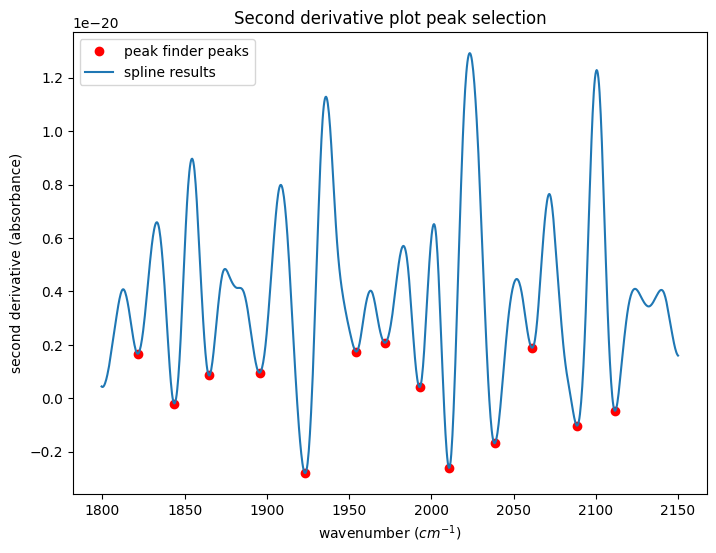

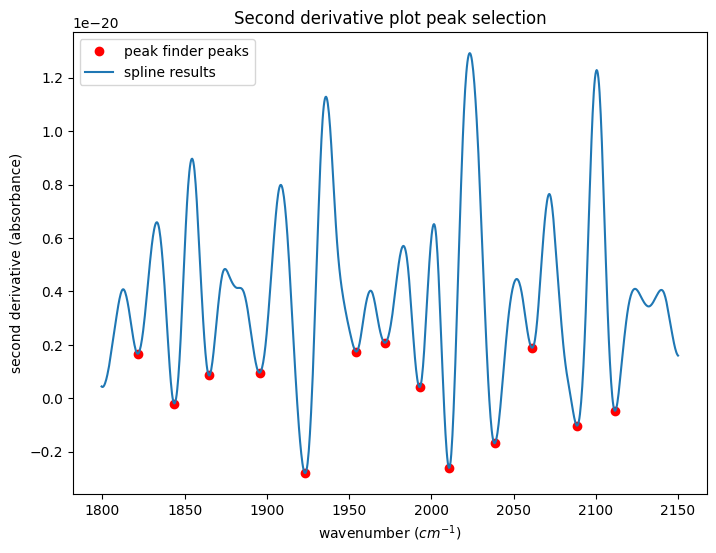

In [29]:
interact(FILL_IN_raw_data,0.4,1.8)

# Baseline correction and cruve fit for an example spectra workflow:

## Fit baseline spline through these anchor points to be used for baseline correction of raw spectra

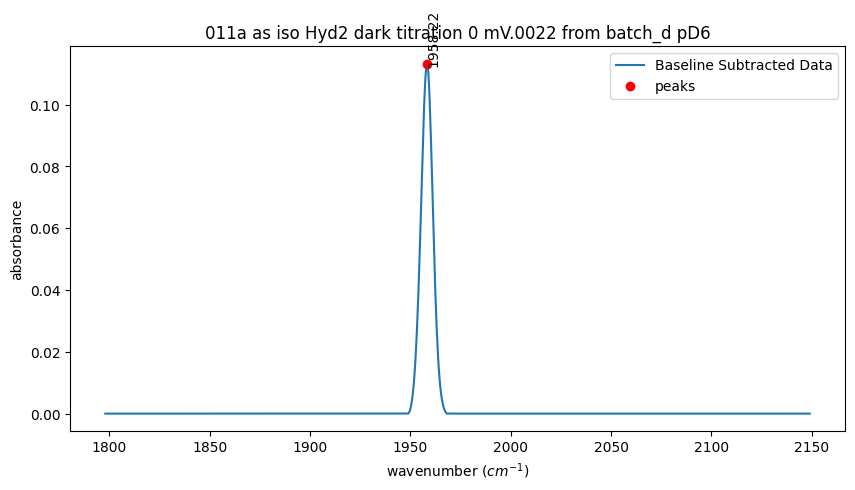

Plot saved to ../data/output_plots//pD6/011a as iso Hyd2 dark titration 0 mV.0022/baseline_subtracted_spectra
Baseline corrected csv data saved to ../data/output_plots//pD6/011a as iso Hyd2 dark titration 0 mV.0022/baseline_corrected_data.csv
Baseline corrected peak info saved to ../data/output_plots//pD6/011a as iso Hyd2 dark titration 0 mV.0022/baseline_corrected_peak_info.csv
Please set and save the thresholds and adjustment factor for baseline spline!
Please set and save the thresholds and adjustment factor for baseline spline!


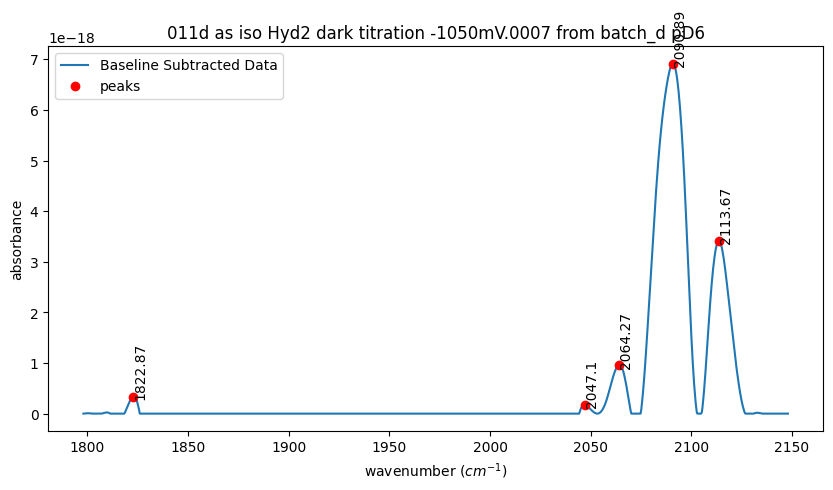

Plot saved to ../data/output_plots//pD6/011d as iso Hyd2 dark titration -1050mV.0007/baseline_subtracted_spectra
Baseline corrected csv data saved to ../data/output_plots//pD6/011d as iso Hyd2 dark titration -1050mV.0007/baseline_corrected_data.csv
Baseline corrected peak info saved to ../data/output_plots//pD6/011d as iso Hyd2 dark titration -1050mV.0007/baseline_corrected_peak_info.csv
Please set and save the thresholds and adjustment factor for baseline spline!
Please set and save the thresholds and adjustment factor for baseline spline!
Please set and save the thresholds and adjustment factor for baseline spline!
Please set and save the thresholds and adjustment factor for baseline spline!
Please set and save the thresholds and adjustment factor for baseline spline!
Please set and save the thresholds and adjustment factor for baseline spline!
Please set and save the thresholds and adjustment factor for baseline spline!
Please set and save the thresholds and adjustment factor for ba

In [30]:
baseline_correction_prospecpy_objects(demo_raw_data, showplot = True, save = True, verbose = True)

# Fitting gaussian and lorentizian curves on the baseline corrected data

Please keep in mind, as of May 2nd, 2025, the following cells do not reliably fit functions to the baseline corrected curves. We have an open [issue](https://github.com/ProSpecPy/ProSpecPy/issues/12) to revert to a prior version of the software where users can enter their own guesses for the peaks, and fit the functions like so.

In [31]:
test_object = demo_raw_data[0]
test_object.baseline_corrected_abs


[np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float6

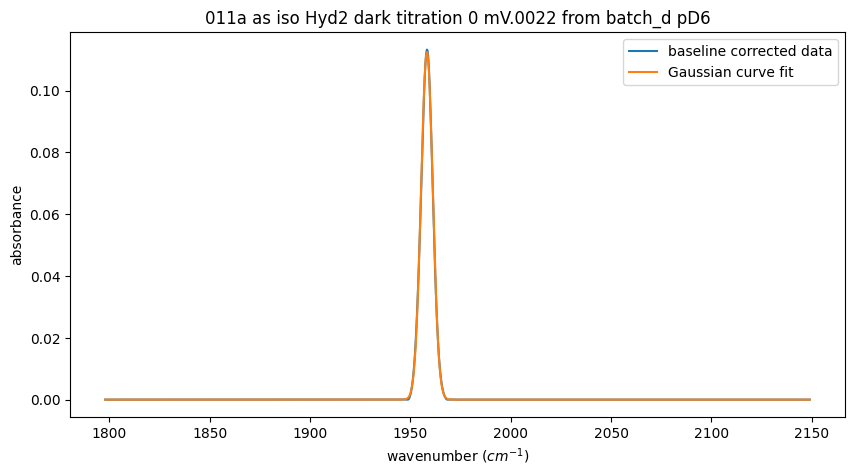

Plot saved to ../data/output_plots//pD6/011a as iso Hyd2 dark titration 0 mV.0022/gaussian_fit_plot
Gaussian csv data saved to ../data/output_plots//pD6/011a as iso Hyd2 dark titration 0 mV.0022/gaussian_fit_params.csv
An error occurred: Optimal parameters not found: Number of calls to function has reached maxfev = 3200.


In [32]:
gaussian_fit_prospecpy_objects(demo_raw_data, show_plots = True, save = True, verbose = True)

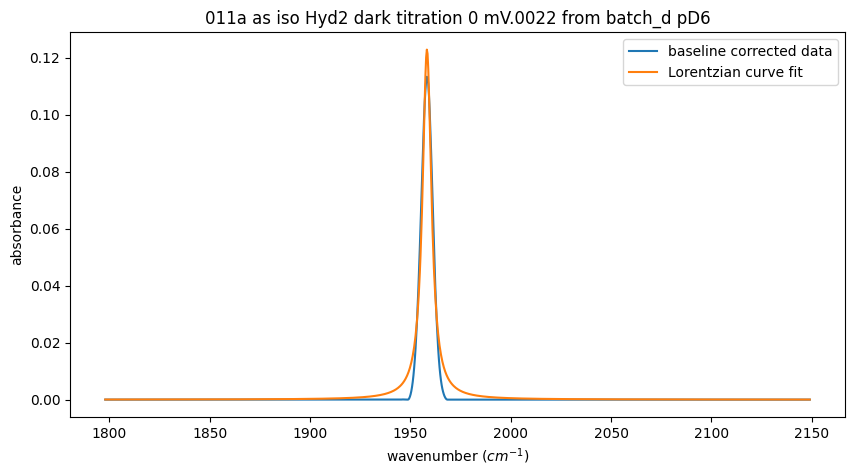

Plot saved to ../data/output_plots//pD6/011a as iso Hyd2 dark titration 0 mV.0022/lorentzian_fit_plot
Lorentzian csv data saved to ../data/output_plots//pD6/011a as iso Hyd2 dark titration 0 mV.0022/lorentzian_fit_params.csv
An error occurred: Optimal parameters not found: Number of calls to function has reached maxfev = 3200.


In [33]:
lorentzian_fit_prospecpy_objects(demo_raw_data, show_plots = True, save = True, verbose = True)